# Experimento 1 - Intervenciones do(Y=y) sobre el SCM triangulo (ruido aditivo Exponencial)

Mismo protocolo que los notebooks de `Observacional/`, pero evaluando el modelo **bajo
intervencion**: grafo X -> Y, X -> Z, Y -> Z, ruido aditivo Exponencial centrado.

**Barrido:** 20 semillas (42-61) x N de entrenamiento en {50, 100, 300, 500} x 11 valores de
beta (peso de HSIC, de 0.0 a 1.0 en pasos de 0.1) x 2 intervenciones, `do(Y=1)` y `do(Y=0)`.
Los dos valores de intervencion reutilizan el mismo modelo entrenado, asi que `do(Y=0)` no
cuesta entrenamiento adicional.

**Conjuntos de evaluacion fijos (N=100, semilla 9999)**, generados una sola vez para que todas
las filas sean comparables entre si: uno observacional y uno por cada valor de `do(Y=y)`.

**Metricas.** Bajo `do(Y=y)` la columna Y es constante, asi que las metricas del nodo Y no son
interpretables sobre datos intervencionales (su "residuo" seria `y - f(X)`, no ruido) y
`HSIC(Z,Y)` esta indefinida contra una constante. Por eso:

| Metrica | En el CSV | Se pinta | De donde sale |
|---|---|---|---|
| `MSE Z`, `MAE Z` | si | si | residuo de Z sobre el conjunto `do(Y=y)` |
| `HSIC(Z,X)` | si | si | independencia del residuo bajo la distribucion desplazada |
| `dHSIC Total` | si | si | `dHSIC(X, rZ)` sobre el conjunto `do(Y=y)` (2 variables, no 3) |
| `MMD`, `RF Acc` | si | si | muestras del modelo vs. ground truth bajo `do(Y=y)` |
| `MSE Y`, `MAE Y`, `HSIC(Y,X)` | si | no | control, sobre el conjunto **observacional** fijo |
| `HSIC(Z,Y)` | si (`NaN`) | no | indefinida con Y constante |

Las graficas observacionales de las metricas de Y ya estan en `Observacional/`, por eso aqui
solo se pintan las 6 metricas que responden a la intervencion.

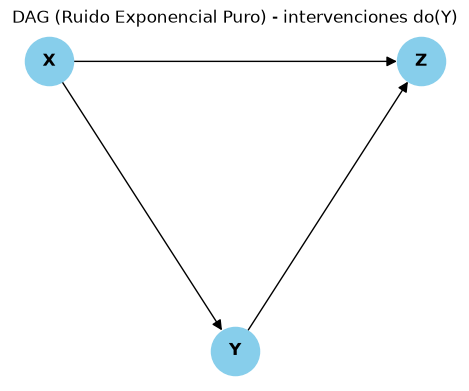


######################################################################
INICIANDO EXPERIMENTO 1 PARA SEMILLA = 42
######################################################################

INICIANDO EXPERIMENTO PARA N = 50
 -> Entrenando MSE para N=50 y semilla=42...
Using device: cpu
Early stopping at step 233
Using device: cpu
Early stopping at step 108
 -> Entrenando HSIC para N=50 y semilla=42...
Using device: cpu
Early stopping at step 277
Using device: cpu
Early stopping at step 31
 -> Entrenando HYBRID_ALPHA0.1 para N=50 y semilla=42...
Using device: cpu
Early stopping at step 373
Using device: cpu
Early stopping at step 142
 -> Entrenando HYBRID_ALPHA0.2 para N=50 y semilla=42...
Using device: cpu
Early stopping at step 759
Using device: cpu
Early stopping at step 119
 -> Entrenando HYBRID_ALPHA0.3 para N=50 y semilla=42...
Using device: cpu
Early stopping at step 275
Using device: cpu
Early stopping at step 122
 -> Entrenando HYBRID_ALPHA0.4 para N=50 y semilla=42...
Using device

KeyboardInterrupt: 

In [2]:
# ==============================================================================
# PASOS 1-5: SETUP, BUCLE PRINCIPAL, TABLA MAESTRA Y CSV
# ==============================================================================
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))

import re
import numpy as np
import pandas as pd
import networkx as nx
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils.metrics import HSIC, dHSIC, mmd, rf
from src.models.kan import hsic_loss, kan_model_mixed


# --- [PASO 1: FUNCIONES AUXILIARES] ---

def muestras_ruido(n, escala):
    """Ruido exponencial centrado restandole su media (media 0, varianza escala**2)."""
    return np.random.exponential(scale=escala, size=n) - escala


def generate_synthetic_triangle_data(num_samples=2000, seed=42, escala=1.0):
    """SCM no lineal en triangulo (X->Y, X->Z, Y->Z) con ruido aditivo Exponencial centrado."""
    np.random.seed(seed)
    eps_X = muestras_ruido(num_samples, escala)
    eps_Y = muestras_ruido(num_samples, escala)
    eps_Z = muestras_ruido(num_samples, escala)

    X = eps_X
    Y = 0.5 * (X ** 2) + np.sin(X) + eps_Y
    Z = 0.7 * X + 0.4 * (Y ** 2) - np.cos(Y) + eps_Z
    return pd.DataFrame({'X': X, 'Y': Y, 'Z': Z})


def gt_interventional(node, value, n, seed=0, escala=1.0):
    """Oraculo: muestras del SCM VERDADERO bajo do(node = value), mismo ruido que el generador."""
    np.random.seed(seed)
    eps_X = muestras_ruido(n, escala)
    eps_Y = muestras_ruido(n, escala)
    eps_Z = muestras_ruido(n, escala)

    X = np.full(n, value) if node == 'X' else eps_X
    Y = np.full(n, value) if node == 'Y' else 0.5 * (X ** 2) + np.sin(X) + eps_Y
    Z = 0.7 * X + 0.4 * (Y ** 2) - np.cos(Y) + eps_Z
    return pd.DataFrame({'X': X, 'Y': Y, 'Z': Z})


def model_intervention(model, node, value, n, seed=42):
    """Muestras del MODELO KAN bajo do(node = value)."""
    # v=value captura el valor por defecto; un cierre libre colapsaria todo el bucle al ultimo valor
    intervention = {node: (lambda _, v=value: v)}
    return model.interventional_samples(intervention, num_samples_to_draw=n, seed=seed)[['X', 'Y', 'Z']]


def crear_estructura_nodos(grafo, params_base, loss_name, alpha, beta, node_types, num_classes):
    """Empaqueta la configuracion de pesos por nodo requerida por kan_model_mixed."""
    config_nodos = {}
    for nodo in grafo.nodes():
        nodo_params = params_base.copy()
        nodo_params['loss'] = loss_name
        nodo_params['alpha_weight'] = alpha
        nodo_params['beta_weight'] = beta
        nodo_params['node_types'] = node_types
        nodo_params['num_classes'] = num_classes
        config_nodos[nodo] = nodo_params
    return config_nodos


def preparar_residuo(res):
    """Convierte tensores de Torch o arrays a numpy array plano de forma segura."""
    if hasattr(res, 'detach'): res = res.detach()
    if hasattr(res, 'cpu'): res = res.cpu()
    return np.array(res).flatten()


# --- [PASO 2: CONFIGURACION DEL EXPERIMENTO] ---

# N_actual es directamente el numero de muestras de ENTRENAMIENTO.
valores_N_experimento = [50, 100, 300, 500]
valores_alpha_candidatos = np.linspace(0.0, 1.0, num=11)  # beta = 1 - alpha
semillas_experimento = np.arange(42, 62)  # 20 semillas
VALORES_Y_DO = [1.0, 0.0]  # las dos intervenciones do(Y=y) que evaluamos

# Orden canonico de las metricas en la tabla final
COLUMNAS_METRICAS = ['MSE Y', 'MAE Y', 'HSIC(Y,X)', 'MSE Z', 'MAE Z',
                     'HSIC(Z,X)', 'HSIC(Z,Y)', 'dHSIC Total', 'MMD', 'RF Acc']

graph_triangle = nx.DiGraph([('X', 'Y'), ('X', 'Z'), ('Y', 'Z')])
node_types = {'X': 'continuous', 'Y': 'continuous', 'Z': 'continuous'}
num_classes = {}

# --- CONJUNTOS DE EVALUACION FIJOS ---
# Generados una unica vez con semilla propia (fuera de semillas_experimento) para que ningun
# conjunto de entrenamiento coincida con ellos y todas las filas sean comparables entre si.
N_EVAL_FIJO = 100
SEED_EVAL_FIJO = 9999

# Observacional: solo se usa para las metricas de control del nodo Y
factual_eval_d = generate_synthetic_triangle_data(num_samples=N_EVAL_FIJO, seed=SEED_EVAL_FIJO, escala=1.0)
X_obs = factual_eval_d['X'].to_numpy().flatten()
num_muestras_eval = len(factual_eval_d)

# Intervencional: un ground truth por cada valor de do(Y=y)
eval_int = {y: gt_interventional('Y', y, N_EVAL_FIJO, seed=SEED_EVAL_FIJO, escala=1.0) for y in VALORES_Y_DO}
datos_reales_int = {y: eval_int[y][['X', 'Y', 'Z']].to_numpy() for y in VALORES_Y_DO}

# Dibujar el DAG estructural para la documentacion del TFM
pos = {'X': (0, 1), 'Y': (1, 0), 'Z': (2, 1)}
plt.figure(figsize=(4.5, 3.5))
nx.draw(graph_triangle, pos, with_labels=True, node_size=1200, node_color='skyblue',
        font_size=12, font_weight='bold', arrowsize=15)
plt.title("DAG (Ruido Exponencial Puro) - intervenciones do(Y)")
plt.show()

base_kan_params = {
    'hidden_dim': 5, 'batch_size': -1, 'grid': 5, 'k': 5, 'seed': 42,
    'lr': 0.002, 'early_stop': True, 'steps': 5000, 'lamb': 0.05,
    'lamb_entropy': 0.05, 'sparse_init': False, 'mult_kan': True,
    'try_gpu': False, 'verbose': 0
}

registros_tabla_final = []

# Modelos que se guardan para los histogramas cualitativos del ultimo paso
SEED_SHOWCASE, N_SHOWCASE = 42, 500
models_showcase = {}


# --- [PASO 3: BUCLE PRINCIPAL DE ENTRENAMIENTO Y EVALUACION] ---

for experiment_id, seed in enumerate(semillas_experimento, start=1):
    print("\n" + "#" * 70)
    print(f"INICIANDO EXPERIMENTO {experiment_id} PARA SEMILLA = {seed}")
    print("#" * 70)

    for N_actual in valores_N_experimento:
        print("\n" + "=" * 70)
        print(f"INICIANDO EXPERIMENTO PARA N = {N_actual}")
        print("=" * 70)

        # El conjunto de entrenamiento cambia con (semilla, N); los de evaluacion son fijos.
        factual_train_d = generate_synthetic_triangle_data(num_samples=N_actual, seed=seed, escala=1.0)

        strategies = ['mse', 'hsic'] + [f"hybrid_alpha{round(a, 2)}" for a in valores_alpha_candidatos
                                        if a != 0.0 and a != 1.0]

        for strategy_key in strategies:
            if strategy_key == "mse":
                strategy_name, alpha_val, beta_val = "mse", 1.0, 0.0
            elif strategy_key == "hsic":
                strategy_name, alpha_val, beta_val = "hsic", 0.0, 1.0
            else:
                strategy_name = "hybrid"
                alpha_val = round(float(re.findall(r"[-+]?\d*\.\d+|\d+", strategy_key)[0]), 2)
                beta_val = round(1.0 - alpha_val, 2)

            params_estructurados = crear_estructura_nodos(
                graph_triangle, base_kan_params, strategy_name, alpha_val, beta_val, node_types, num_classes
            )

            print(f" -> Entrenando {strategy_key.upper()} para N={N_actual} y semilla={seed}...")
            model = kan_model_mixed(graph_triangle, params_estructurados)
            model.fit(data=factual_train_d)

            if seed == SEED_SHOWCASE and N_actual == N_SHOWCASE:
                models_showcase[beta_val] = model

            conf_name = strategy_key.upper() if strategy_name != "hybrid" else f"HYBRID_ALPHA{alpha_val}_BETA{beta_val}"

            # Metricas de control del nodo Y: se miden sobre el conjunto OBSERVACIONAL fijo, porque
            # bajo do(Y=y) la Y es constante y su residuo dejaria de ser ruido. Son identicas para
            # las dos intervenciones a proposito.
            metricas_y = {}
            try:
                residuos_obs = model.get_residuals(factual_eval_d)
                if 'Y' in residuos_obs and residuos_obs['Y'] is not None:
                    rY = preparar_residuo(residuos_obs['Y'])
                    metricas_y['MSE Y'] = round(float(np.mean(rY ** 2)), 5)
                    metricas_y['MAE Y'] = round(float(np.mean(np.abs(rY))), 5)
                    metricas_y['HSIC(Y,X)'] = round(float(HSIC(rY, X_obs)), 5)
            except Exception as e:
                print(f"   [Error en metricas de control de Y] {conf_name}, N={N_actual}: {e}")

            # Un modelo entrenado -> una fila por cada valor de do(Y=y)
            for y_do in VALORES_Y_DO:
                fila = {
                    'Experiment': experiment_id,
                    'Seed': seed,
                    'Loss': strategy_name,
                    'Conf': conf_name,
                    'Alpha': alpha_val,
                    'Beta': beta_val,
                    'N': N_actual,
                    'Y_do': y_do,
                }
                fila.update(metricas_y)
                fila['HSIC(Z,Y)'] = np.nan  # Y es constante bajo do(Y=y): HSIC no esta definida

                try:
                    df_int_gt = eval_int[y_do]
                    X_int = df_int_gt['X'].to_numpy().flatten()

                    residuos_int = model.get_residuals(df_int_gt)
                    if 'Z' in residuos_int and residuos_int['Z'] is not None:
                        rZ = preparar_residuo(residuos_int['Z'])
                        fila['MSE Z'] = round(float(np.mean(rZ ** 2)), 5)
                        fila['MAE Z'] = round(float(np.mean(np.abs(rZ))), 5)
                        fila['HSIC(Z,X)'] = round(float(HSIC(rZ, X_int)), 5)
                        fila['dHSIC Total'] = round(float(max(0.0, dHSIC(X_int, rZ))), 5)

                    datos_gen = model_intervention(model, 'Y', y_do, num_muestras_eval).to_numpy()
                    fila['MMD'] = round(float(max(0.0, mmd(datos_reales_int[y_do], datos_gen))), 5)
                    fila['RF Acc'] = round(float(rf(datos_reales_int[y_do], datos_gen)), 5)

                except Exception as e:
                    print(f"   [Error en evaluacion] {conf_name}, N={N_actual}, do(Y={y_do}): {e}")

                registros_tabla_final.append(fila)


# --- [PASO 4: CONSTRUCCION DE LA TABLA MAESTRA] ---
df_final_multi_n = pd.DataFrame(registros_tabla_final)
df_final_multi_n['es_hibrido'] = df_final_multi_n['Conf'].str.contains('HYBRID')
df_final_multi_n = df_final_multi_n.sort_values(
    by=['Experiment', 'Seed', 'Loss', 'N', 'Y_do', 'es_hibrido', 'Alpha', 'Beta'],
    ascending=[True, True, True, True, False, True, True, True])

base_cols = ['Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N', 'Y_do']
metric_cols = [c for c in COLUMNAS_METRICAS if c in df_final_multi_n.columns]
df_final_multi_n = df_final_multi_n[base_cols + metric_cols]

print("\n--- MATRIZ DE DIAGNOSTICO INTERVENCIONAL MULTI-N FINALIZADA ---")
display(df_final_multi_n)


# --- [PASO 5: GUARDADO DE RESULTADOS EN CSV] ---
carpeta_tablas = "tablas"
if not os.path.exists(carpeta_tablas):
    os.makedirs(carpeta_tablas)

ruta_archivo = os.path.join(carpeta_tablas, "intervencional_aditivo_exponencial.csv")
df_final_multi_n.to_csv(ruta_archivo, index=False)
print(f"\nTabla maestra guardada en: {ruta_archivo}")

In [ ]:
# ==============================================================================
# PASO 6: TABLA RESUMEN CON MEDIA Y DESVIACION TIPICA
# Media +- Std de cada combinacion (Alpha, Beta) a traves de las semillas,
# por separado para cada N y cada valor de do(Y=y).
# ==============================================================================
print("\n" + "=" * 100)
print("TABLA RESUMEN: MEDIA +- DESVIACION TIPICA POR (N, do(Y=y), ALPHA-BETA)")
print("=" * 100)

cols_excluidas = {'Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N', 'Y_do', 'es_hibrido'}
metricas_numericas = [col for col in df_final_multi_n.columns if col not in cols_excluidas]

for n_val in sorted(df_final_multi_n['N'].unique()):
    for y_do in VALORES_Y_DO:
        df_slice = df_final_multi_n[(df_final_multi_n['N'] == n_val) & (df_final_multi_n['Y_do'] == y_do)].copy()
        if df_slice.empty:
            continue

        print(f"\n\n{'#' * 100}")
        print(f"# EXPERIMENTO: N = {n_val} MUESTRAS  |  do(Y = {y_do})")
        print(f"{'#' * 100}\n")

        resumen_por_config = []
        for (alpha_val, beta_val), group_config in df_slice.groupby(['Alpha', 'Beta']):
            fila_resumen = {
                'Alpha': alpha_val,
                'Beta': beta_val,
                'Y_do': y_do,
                'Loss': group_config['Loss'].iloc[0],
                'Conf': group_config['Conf'].iloc[0],
                'Num_Seeds': len(group_config),
            }
            for metrica in metricas_numericas:
                fila_resumen[f'{metrica}_mean'] = round(group_config[metrica].mean(), 5)
                fila_resumen[f'{metrica}_std'] = round(group_config[metrica].std(), 5)
            resumen_por_config.append(fila_resumen)

        df_resumen_n = pd.DataFrame(resumen_por_config)

        orden_loss = {'mse': 0, 'hsic': 1, 'hybrid': 2}
        df_resumen_n['loss_order'] = df_resumen_n['Loss'].map(orden_loss)
        df_resumen_n = df_resumen_n.sort_values(['loss_order', 'Alpha'], ascending=[True, False])
        df_resumen_n = df_resumen_n.drop('loss_order', axis=1)

        print(f"Tabla resumen para N={n_val}, do(Y={y_do}):\n")
        display(df_resumen_n)

        if not os.path.exists("tablas"):
            os.makedirs("tablas")
        ruta_resumen_n = os.path.join(
            "tablas", f"resumen_n_{n_val}_ydo_{y_do}_intervencional_aditivo_exponencial.csv")
        df_resumen_n.to_csv(ruta_resumen_n, index=False)
        print(f"\nTabla resumen guardada en: {ruta_resumen_n}\n")


# Version legible "media +- std" para copiar a la memoria del TFM
print(f"\n\n{'=' * 100}")
print("FORMATO LEGIBLE: Media +- Std para cada metrica")
print(f"{'=' * 100}\n")

for n_val in sorted(df_final_multi_n['N'].unique()):
    for y_do in VALORES_Y_DO:
        df_slice = df_final_multi_n[(df_final_multi_n['N'] == n_val) & (df_final_multi_n['Y_do'] == y_do)].copy()
        if df_slice.empty:
            continue

        print(f"\n{'#' * 100}")
        print(f"# N = {n_val} MUESTRAS  |  do(Y = {y_do})")
        print(f"{'#' * 100}\n")

        for (alpha_val, beta_val), group_config in df_slice.groupby(['Alpha', 'Beta']):
            conf_name = group_config['Conf'].iloc[0]
            loss_name = group_config['Loss'].iloc[0]

            print(f"\n{'-' * 100}")
            print(f"Config: {conf_name:30s} | Alpha={alpha_val:.2f}, Beta={beta_val:.2f}, "
                  f"Loss={loss_name} | Seeds: {len(group_config)}")
            print(f"{'-' * 100}")

            resumen_row = {}
            for metrica in metricas_numericas:
                media = group_config[metrica].mean()
                std = group_config[metrica].std()
                resumen_row[metrica] = f"{media:.5f} +- {std:.5f}"

            df_readable = pd.DataFrame([resumen_row]).T
            df_readable.columns = ['Media +- Std']
            display(df_readable)


TABLA RESUMEN: MEDIA +- DESVIACION TIPICA POR (N, do(Y=y), ALPHA-BETA)


####################################################################################################
# EXPERIMENTO: N = 50 MUESTRAS  |  do(Y = 1.0)
####################################################################################################

Tabla resumen para N=50, do(Y=1.0):



,Alpha,Beta,Y_do,Loss,Conf,Num_Seeds,MSE Y_mean,MSE Y_std,MAE Y_mean,MAE Y_std,...,"HSIC(Z,X)_mean","HSIC(Z,X)_std","HSIC(Z,Y)_mean","HSIC(Z,Y)_std",dHSIC Total_mean,dHSIC Total_std,MMD_mean,MMD_std,RF Acc_mean,RF Acc_std
10,1.0,0.0,1.0,mse,MSE,20,0.80616,0.15833,0.72078,0.07770,...,0.10229,0.02169,NaN,NaN,0.01088,0.00171,0.06615,0.03206,0.66500,0.05343
0,0.0,1.0,1.0,hsic,HSIC,20,1.04612,0.29213,0.75839,0.14135,...,0.16679,0.04963,NaN,NaN,0.01107,0.00733,0.21225,0.09791,0.79750,0.08425
9,0.9,0.1,1.0,hybrid,HYBRID_ALPHA0.9_BETA0.1,20,0.80683,0.16967,0.71749,0.08263,...,0.09677,0.02761,NaN,NaN,0.01082,0.00170,0.06762,0.03365,0.66500,0.04088
8,0.8,0.2,1.0,hybrid,HYBRID_ALPHA0.8_BETA0.2,20,0.80466,0.16929,0.71659,0.07798,...,0.09397,0.02965,NaN,NaN,0.01088,0.00177,0.06938,0.03758,0.66750,0.04523
7,0.7,0.3,1.0,hybrid,HYBRID_ALPHA0.7_BETA0.3,20,0.79634,0.16022,0.71109,0.07695,...,0.09096,0.02864,NaN,NaN,0.01119,0.00187,0.06664,0.03875,0.68125,0.04721
6,0.6,0.4,1.0,hybrid,HYBRID_ALPHA0.6_BETA0.4,20,0.79401,0.16140,0.71266,0.07668,...,0.09086,0.02839,NaN,NaN,0.01140,0.00209,0.06696,0.03863,0.66500,0.05701
5,0.5,0.5,1.0,hybrid,HYBRID_ALPHA0.5_BETA0.5,20,0.79933,0.16177,0.70913,0.07849,...,0.09400,0.02968,NaN,NaN,0.01176,0.00244,0.06855,0.03824,0.66750,0.05072
4,0.4,0.6,1.0,hybrid,HYBRID_ALPHA0.4_BETA0.6,20,0.77367,0.16243,0.69896,0.07955,...,0.09234,0.03414,NaN,NaN,0.01157,0.00265,0.06887,0.04062,0.67375,0.04328
3,0.3,0.7,1.0,hybrid,HYBRID_ALPHA0.3_BETA0.7,20,0.78144,0.17285,0.70058,0.08139,...,0.08970,0.03446,NaN,NaN,0.01156,0.00279,0.07022,0.04159,0.67125,0.04679
2,0.2,0.8,1.0,hybrid,HYBRID_ALPHA0.2_BETA0.8,20,0.77204,0.13797,0.69064,0.07663,...,0.08935,0.03246,NaN,NaN,0.01185,0.00306,0.06747,0.03961,0.66500,0.05525



Tabla resumen guardada en: tablas\resumen_n_50_ydo_1.0_intervencional_aditivo_exponencial.csv



####################################################################################################
# EXPERIMENTO: N = 50 MUESTRAS  |  do(Y = 0.0)
####################################################################################################

Tabla resumen para N=50, do(Y=0.0):



,Alpha,Beta,Y_do,Loss,Conf,Num_Seeds,MSE Y_mean,MSE Y_std,MAE Y_mean,MAE Y_std,...,"HSIC(Z,X)_mean","HSIC(Z,X)_std","HSIC(Z,Y)_mean","HSIC(Z,Y)_std",dHSIC Total_mean,dHSIC Total_std,MMD_mean,MMD_std,RF Acc_mean,RF Acc_std
10,1.0,0.0,0.0,mse,MSE,20,0.80616,0.15833,0.72078,0.07770,...,0.12202,0.02586,NaN,NaN,0.01020,0.00184,0.10231,0.04768,0.66625,0.06138
0,0.0,1.0,0.0,hsic,HSIC,20,1.04612,0.29213,0.75839,0.14135,...,0.16185,0.05609,NaN,NaN,0.01056,0.00703,0.25523,0.07950,0.82375,0.04831
9,0.9,0.1,0.0,hybrid,HYBRID_ALPHA0.9_BETA0.1,20,0.80683,0.16967,0.71749,0.08263,...,0.12006,0.02522,NaN,NaN,0.01023,0.00200,0.10324,0.05150,0.66625,0.06349
8,0.8,0.2,0.0,hybrid,HYBRID_ALPHA0.8_BETA0.2,20,0.80466,0.16929,0.71659,0.07798,...,0.11617,0.03000,NaN,NaN,0.01023,0.00232,0.10061,0.05259,0.67000,0.05477
7,0.7,0.3,0.0,hybrid,HYBRID_ALPHA0.7_BETA0.3,20,0.79634,0.16022,0.71109,0.07695,...,0.11564,0.02770,NaN,NaN,0.01023,0.00273,0.09836,0.04602,0.67000,0.05537
6,0.6,0.4,0.0,hybrid,HYBRID_ALPHA0.6_BETA0.4,20,0.79401,0.16140,0.71266,0.07668,...,0.11564,0.02777,NaN,NaN,0.01038,0.00268,0.09679,0.04599,0.66750,0.04940
5,0.5,0.5,0.0,hybrid,HYBRID_ALPHA0.5_BETA0.5,20,0.79933,0.16177,0.70913,0.07849,...,0.12010,0.02793,NaN,NaN,0.01080,0.00298,0.10064,0.04704,0.68375,0.05976
4,0.4,0.6,0.0,hybrid,HYBRID_ALPHA0.4_BETA0.6,20,0.77367,0.16243,0.69896,0.07955,...,0.11566,0.03270,NaN,NaN,0.01028,0.00222,0.10012,0.04938,0.67875,0.05458
3,0.3,0.7,0.0,hybrid,HYBRID_ALPHA0.3_BETA0.7,20,0.78144,0.17285,0.70058,0.08139,...,0.11564,0.03177,NaN,NaN,0.01028,0.00259,0.09920,0.04867,0.67875,0.06349
2,0.2,0.8,0.0,hybrid,HYBRID_ALPHA0.2_BETA0.8,20,0.77204,0.13797,0.69064,0.07663,...,0.11600,0.02565,NaN,NaN,0.01076,0.00250,0.09875,0.04888,0.67250,0.06584



Tabla resumen guardada en: tablas\resumen_n_50_ydo_0.0_intervencional_aditivo_exponencial.csv



####################################################################################################
# EXPERIMENTO: N = 100 MUESTRAS  |  do(Y = 1.0)
####################################################################################################

Tabla resumen para N=100, do(Y=1.0):



...

,Media +- Std
MSE Y,0.62291 +- 0.01942
MAE Y,0.64098 +- 0.01754
"HSIC(Y,X)",0.02686 +- 0.00647
MSE Z,1.12509 +- 0.39649
MAE Z,0.84702 +- 0.18594
"HSIC(Z,X)",0.08148 +- 0.04689
"HSIC(Z,Y)",nan +- nan
dHSIC Total,0.00867 +- 0.00227
MMD,0.07837 +- 0.05686
RF Acc,0.66875 +- 0.06224



----------------------------------------------------------------------------------------------------
Config: HYBRID_ALPHA0.9_BETA0.1        | Alpha=0.90, Beta=0.10, Loss=hybrid | Seeds: 20
----------------------------------------------------------------------------------------------------


,Media +- Std
MSE Y,0.62290 +- 0.01856
MAE Y,0.64123 +- 0.01765
"HSIC(Y,X)",0.02867 +- 0.00800
MSE Z,1.10101 +- 0.36522
MAE Z,0.83719 +- 0.17533
"HSIC(Z,X)",0.07901 +- 0.04344
"HSIC(Z,Y)",nan +- nan
dHSIC Total,0.00858 +- 0.00236
MMD,0.07667 +- 0.05352
RF Acc,0.67000 +- 0.06718



----------------------------------------------------------------------------------------------------
Config: MSE                            | Alpha=1.00, Beta=0.00, Loss=mse | Seeds: 20
----------------------------------------------------------------------------------------------------


,Media +- Std
MSE Y,0.62448 +- 0.01876
MAE Y,0.64263 +- 0.01763
"HSIC(Y,X)",0.03154 +- 0.01040
MSE Z,1.21351 +- 0.34189
MAE Z,0.90334 +- 0.16275
"HSIC(Z,X)",0.10532 +- 0.04094
"HSIC(Z,Y)",nan +- nan
dHSIC Total,0.00887 +- 0.00152
MMD,0.08813 +- 0.04723
RF Acc,0.64875 +- 0.05031


In [ ]:
# ==============================================================================
# PASO 7: VISUALIZACION CON MEDIA +- DESVIACION TIPICA (BAND PLOTS)
# Todas las N en una misma grafica, organizadas por Beta, y una figura por do(Y=y).
#
# Beta = 1 (HSIC puro) se pinta en un EJE Y SECUNDARIO (derecha) con su propia escala,
# para que su posible subida no comprima/deforme la escala del resto de Betas (0 a 0.9,
# eje izquierdo). El ancho del eje derecho es el MAXIMO de tres necesidades:
#   1) Contencion: que quepan todos los puntos de Beta=1 con su barra de error.
#   2) Estetica moderada: al menos FACTOR_ANCHO_MAX veces el ancho del eje izquierdo.
#   3) Subida garantizada por N: para CADA N cuya subida sea real (Beta=1 > Beta=0.9),
#      el ancho minimo para que esa curva concreta se vea subir.
# Si el valor real de Beta=1 NO es mayor que el de Beta=0.9, la linea baja: eso es honesto.
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import ConnectionPatch, Polygon

# Solo las metricas que responden a la intervencion. Las de Y (control) y HSIC(Z,Y)
# (indefinida con Y constante) se quedan en el CSV pero no se pintan: sus graficas
# observacionales ya estan en los notebooks de Observacional/.
METRICAS_PLOT_INTERVENCIONAL = ['MSE Z', 'MAE Z', 'HSIC(Z,X)', 'dHSIC Total', 'MMD', 'RF Acc']
metricas_para_plot = [m for m in METRICAS_PLOT_INTERVENCIONAL if m in df_final_multi_n.columns]

print("\n" + "=" * 100)
print("VISUALIZACION INTERVENCIONAL: MEDIA Y DESVIACION TIPICA POR METRICA")
print("(Linea = Media | Area sombreada = Media +- Desviacion Tipica)")
print("(Cada color = un tamano de muestra N diferente | una figura por do(Y=y))")
print("(Beta=1, HSIC puro, en eje derecho: subida garantizada para cada N, sin salirse de rango)")
print("=" * 100 + "\n")


def _a_coords_figura(fig_obj, ax_obj, punto):
    """Convierte un punto en coordenadas de datos de ax_obj a coordenadas de la figura."""
    disp = ax_obj.transData.transform(punto)
    return fig_obj.transFigure.inverted().transform(disp)


FACTOR_ANCHO_MAX = 1.4   # ancho minimo "estetico" (en veces el ancho del eje izquierdo)
MARGEN_BORDE = 0.05      # margen extra para que ningun punto quede pegado al borde

if not os.path.exists('plots'):
    os.makedirs('plots')

for y_do in VALORES_Y_DO:
    df_y = df_final_multi_n[df_final_multi_n['Y_do'] == y_do]
    if df_y.empty:
        continue

    # Tabla resumen GLOBAL (todos los N) para esta intervencion
    resumen_global = []
    for n_val in sorted(df_y['N'].unique()):
        df_n = df_y[df_y['N'] == n_val]
        for (alpha, beta), group in df_n.groupby(['Alpha', 'Beta']):
            row = {'N': n_val, 'Alpha': alpha, 'Beta': beta,
                   'Loss': group['Loss'].iloc[0], 'Conf': group['Conf'].iloc[0]}
            for metrica in metricas_para_plot:
                row[f'{metrica}_mean'] = group[metrica].mean()
                row[f'{metrica}_std'] = group[metrica].std()
            resumen_global.append(row)

    df_global = pd.DataFrame(resumen_global)

    # Descartamos metricas sin ningun valor valido para no propagar NaN a los limites de los ejes
    metricas_validas = [m for m in metricas_para_plot if not df_global[f'{m}_mean'].isna().all()]
    if not metricas_validas:
        print(f"[do(Y={y_do})] No hay metricas con valores validos que pintar.")
        continue

    lista_n = sorted(df_global['N'].unique())
    colores_n = sns.color_palette("husl", len(lista_n))
    paleta_n = dict(zip(lista_n, colores_n))

    num_plots = len(metricas_validas)
    fig, axes = plt.subplots(num_plots, 1, figsize=(14, 5 * num_plots))
    if num_plots == 1:
        axes = [axes]

    fig.suptitle(
        f'Interventional Sensitivity Analysis - do(Y = {y_do})\n'
        '(Line = Mean | Area = Mean ± Std | Beta=1 on right axis, increase guaranteed by N)',
        fontsize=14, fontweight='bold', y=0.995)

    for idx, metrica in enumerate(metricas_validas):
        ax = axes[idx]
        ax2 = ax.twinx()  # Eje secundario: SOLO para el punto Beta = 1 (HSIC puro)

        lineas_leyenda, etiquetas_leyenda = [], []
        puntos_beta1 = []  # (color, x_last, y_last, y_std_last, y1_mean, y1_std)

        # 1a pasada: pintar Beta<1 en el eje izquierdo y recopilar los puntos de Beta=1
        for n_val in lista_n:
            df_n_data = df_global[df_global['N'] == n_val].sort_values('Beta')
            color = paleta_n[n_val]

            df_normal = df_n_data[df_n_data['Beta'] < 1.0]
            x = df_normal['Beta'].values
            y_mean = df_normal[f'{metrica}_mean'].values
            y_std = df_normal[f'{metrica}_std'].values

            linea, = ax.plot(x, y_mean, marker='o', linewidth=2.5, label=f'N = {n_val}',
                             color=color, markersize=6)
            ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.15, color=color)
            lineas_leyenda.append(linea)
            etiquetas_leyenda.append(f'N = {n_val}')

            df_beta1 = df_n_data[df_n_data['Beta'] == 1.0]
            if not df_beta1.empty and len(x) > 0:
                y1_mean = float(df_beta1[f'{metrica}_mean'].values[0])
                y1_std = float(df_beta1[f'{metrica}_std'].values[0])
                puntos_beta1.append((color, x[-1], y_mean[-1], y_std[-1], y1_mean, y1_std))

        # 2a pasada: el rango del eje derecho es el MAXIMO de las tres necesidades
        bottom_ax, top_ax = ax.get_ylim()
        rango_ax = (top_ax - bottom_ax) if top_ax > bottom_ax else 1.0

        if puntos_beta1:
            techo_deseado = max(m + s for _, _, _, _, m, s in puntos_beta1)
            suelo_deseado = min(m - s for _, _, _, _, m, s in puntos_beta1)
            margen_abs = MARGEN_BORDE * max(techo_deseado - suelo_deseado, rango_ax)
            top2 = techo_deseado + margen_abs

            ancho_containment = (techo_deseado - suelo_deseado) + 2 * margen_abs
            ancho_moderado = FACTOR_ANCHO_MAX * rango_ax
            anchos_necesarios = [ancho_containment, ancho_moderado]

            for _, x_last, y_last, y_std_last, y1_mean, y1_std in puntos_beta1:
                h_last = (y_last - bottom_ax) / rango_ax
                if y1_mean > y_last and h_last < 0.999:
                    cota_bottom = (y1_mean - h_last * top2) / (1 - h_last) - margen_abs
                    anchos_necesarios.append(top2 - cota_bottom)

            ancho_final = max(anchos_necesarios)
            ax2.set_ylim(top2 - ancho_final, top2)

        # 3a pasada: pintar Beta=1 y conectar tanto la media como la banda
        for color, x_last, y_last, y_std_last, y1_mean, y1_std in puntos_beta1:
            ax2.errorbar([1.0], [y1_mean], yerr=[y1_std], fmt='D', color=color,
                         markersize=8, markeredgecolor='black', markeredgewidth=0.8,
                         capsize=4, elinewidth=1.5, zorder=3)

            con = ConnectionPatch(xyA=(x_last, y_last), coordsA=ax.transData,
                                  xyB=(1.0, y1_mean), coordsB=ax2.transData,
                                  color=color, linewidth=2.5, zorder=1)
            con.set_clip_path(ax.patch)  # recortar al area del propio subgrafico
            fig.add_artist(con)

            p_inf_izq = _a_coords_figura(fig, ax, (x_last, y_last - y_std_last))
            p_inf_der = _a_coords_figura(fig, ax2, (1.0, y1_mean - y1_std))
            p_sup_der = _a_coords_figura(fig, ax2, (1.0, y1_mean + y1_std))
            p_sup_izq = _a_coords_figura(fig, ax, (x_last, y_last + y_std_last))

            banda = Polygon([p_inf_izq, p_inf_der, p_sup_der, p_sup_izq], closed=True,
                            transform=fig.transFigure, facecolor=color, alpha=0.15,
                            edgecolor=None, zorder=0)
            banda.set_clip_path(ax.patch)
            fig.add_artist(banda)

        ax.set_xlabel('Beta (HSIC weight)', fontsize=12, fontweight='bold')
        ax.set_ylabel(metrica, fontsize=12, fontweight='bold')
        ax.set_title(f'Evolution of {metrica} according to N and Beta  -  do(Y = {y_do})',
                     fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.set_xlim(-0.05, 1.05)
        ax.set_xticks(sorted(df_global['Beta'].unique()))
        ax.legend(lineas_leyenda, etiquetas_leyenda, loc='upper left', fontsize=10, ncol=3)

        ax2.set_ylabel(f'{metrica} in Beta=1 (Pure HSIC)', fontsize=10, fontweight='bold', color='dimgray')
        ax2.tick_params(axis='y', labelcolor='dimgray')

    plt.tight_layout()

    ruta_plot = os.path.join('plots', f'bandplot_todas_N_intervencional_ydo_{y_do}_aditivo_exponencial.png')
    plt.savefig(ruta_plot, dpi=300, bbox_inches='tight')
    print(f"Grafica consolidada guardada: {ruta_plot}\n")
    plt.show()

print("Graficas generadas con media +- desviacion tipica (todas las N en una figura por do(Y=y))")

NameError: name 'df_final_multi_n' is not defined

Histogramas guardados: plots\hist_z_do_y_aditivo_exponencial.png


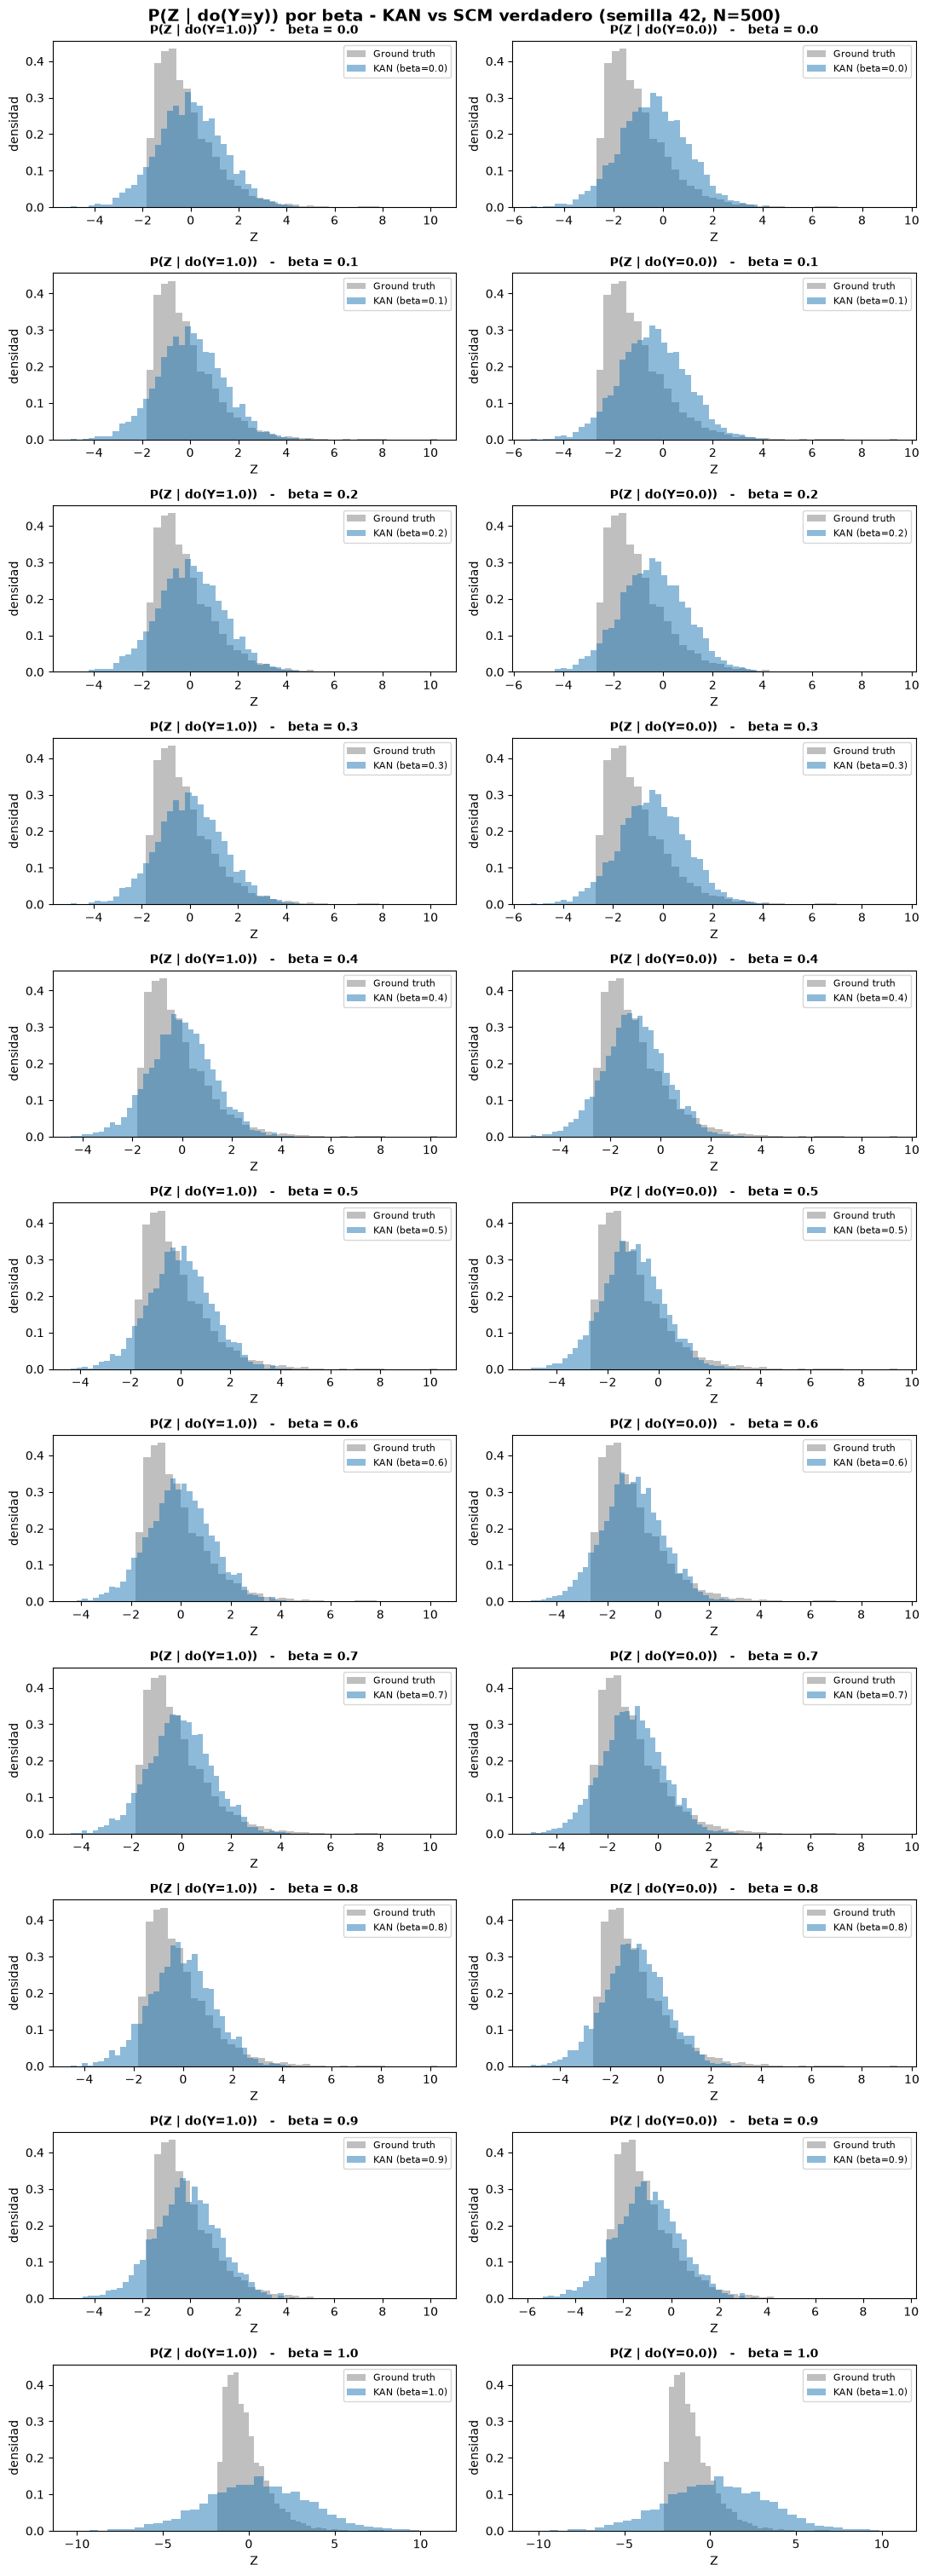

In [ ]:
# ==============================================================================
# PASO 8: HISTOGRAMAS CUALITATIVOS P(Z | do(Y=y)) POR BETA
# Rejilla 11 x 2 (filas = beta, columnas = do(Y=y)) comparando el modelo KAN contra el
# SCM verdadero. Reutiliza los modelos ya entrenados con semilla SEED_SHOWCASE y N_SHOWCASE,
# asi que no reentrena nada. Solo histogramas: sin KDE, sin ATE.
# ==============================================================================
N_HIST = 4000

if not models_showcase:
    print(f"No hay modelos guardados (se esperaban semilla={SEED_SHOWCASE} y N={N_SHOWCASE}). "
          "Ajusta SEED_SHOWCASE / N_SHOWCASE y vuelve a ejecutar el Paso 3.")
else:
    betas_ordenados = sorted(models_showcase)
    fig, axes = plt.subplots(len(betas_ordenados), len(VALORES_Y_DO),
                             figsize=(5.5 * len(VALORES_Y_DO), 2.8 * len(betas_ordenados)),
                             squeeze=False)

    for j, y_do in enumerate(VALORES_Y_DO):
        z_gt = gt_interventional('Y', y_do, N_HIST, seed=0, escala=1.0)['Z']

        for i, beta in enumerate(betas_ordenados):
            ax = axes[i][j]
            z_model = model_intervention(models_showcase[beta], 'Y', y_do, N_HIST, seed=42)['Z']

            ax.hist(z_gt, bins=40, density=True, alpha=0.5, color='gray', label='Ground truth')
            ax.hist(z_model, bins=40, density=True, alpha=0.5, color='tab:blue', label=f'KAN (beta={beta})')
            ax.set_xlabel('Z')
            ax.set_ylabel('densidad')
            ax.set_title(f'P(Z | do(Y={y_do}))   -   beta = {beta}', fontsize=10, fontweight='bold')
            ax.legend(fontsize=8)

    fig.suptitle(f'P(Z | do(Y=y)) por beta - KAN vs SCM verdadero '
                 f'(semilla {SEED_SHOWCASE}, N={N_SHOWCASE})', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.99])

    if not os.path.exists('plots'):
        os.makedirs('plots')
    ruta_hist = os.path.join('plots', 'hist_z_do_y_aditivo_exponencial.png')
    plt.savefig(ruta_hist, dpi=300, bbox_inches='tight')
    print(f"Histogramas guardados: {ruta_hist}")
    plt.show()